In [4]:
import numpy as np
import pandas as pd

from scipy import stats

from mlxtend.preprocessing import minmax_scaling

import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(10)

sns.set_style('whitegrid')

#### Scaling

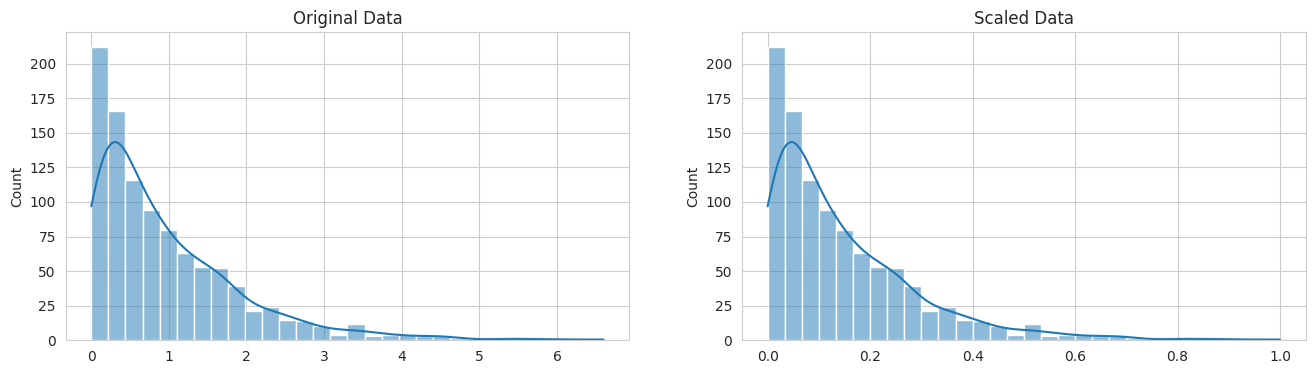

In [6]:
original_data = np.random.exponential(size=1000)

# min-max scale the data between 0 and 1
scaled_data = minmax_scaling(original_data, columns=[0])

# plot both together to compare
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(scaled_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title("Scaled Data")
plt.show()

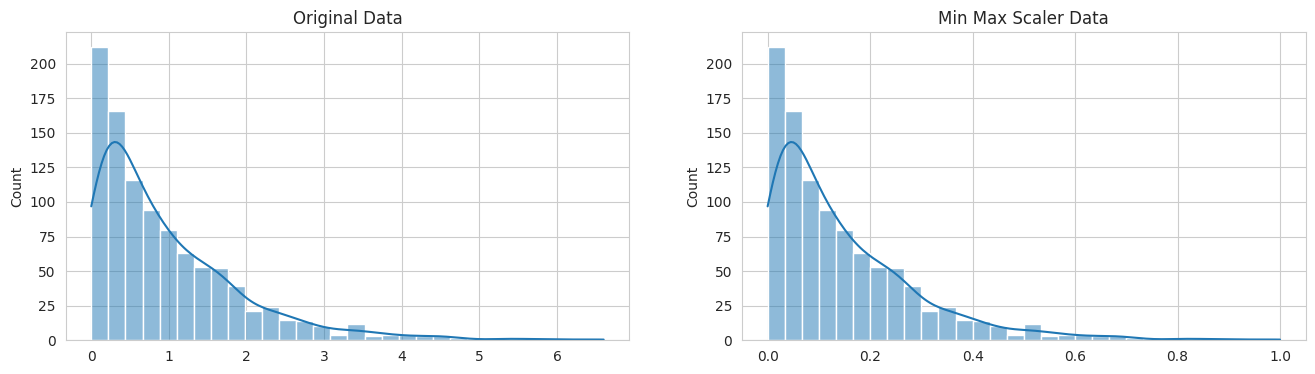

In [13]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

min_max_scaled_data = min_max_scaler.fit_transform(original_data.reshape(-1, 1))

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(min_max_scaled_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title("Min Max Scaler Data")
plt.show()

Min-max scaling (many people call this normalization) is quite simple: values are
shifted and rescaled so that they end up ranging from 0 to 1. We do this by subtract‐
ing the min value and dividing by the max minus the min. Scikit-Learn provides a transformer called MinMaxScaler for this. It has a feature_range hyperparameter
that lets you change the range if you don’t want 0–1 for some reason.

Notice that the *shape* of the data doesn't change, but that instead of ranging from 0 to 8ish, it now ranges from 0 to 1.

#### Normalization

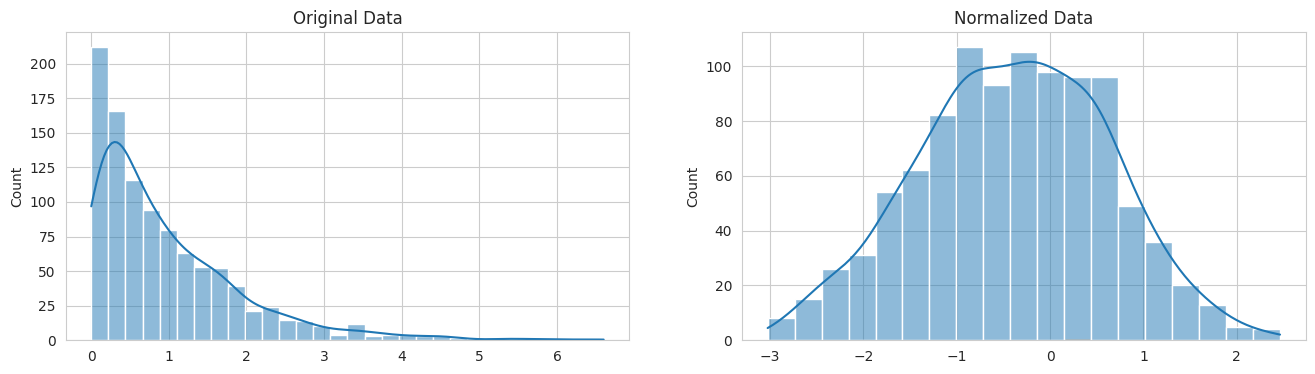

In [5]:
normalized_data = stats.boxcox(original_data)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(normalized_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title("Normalized Data")
plt.show()

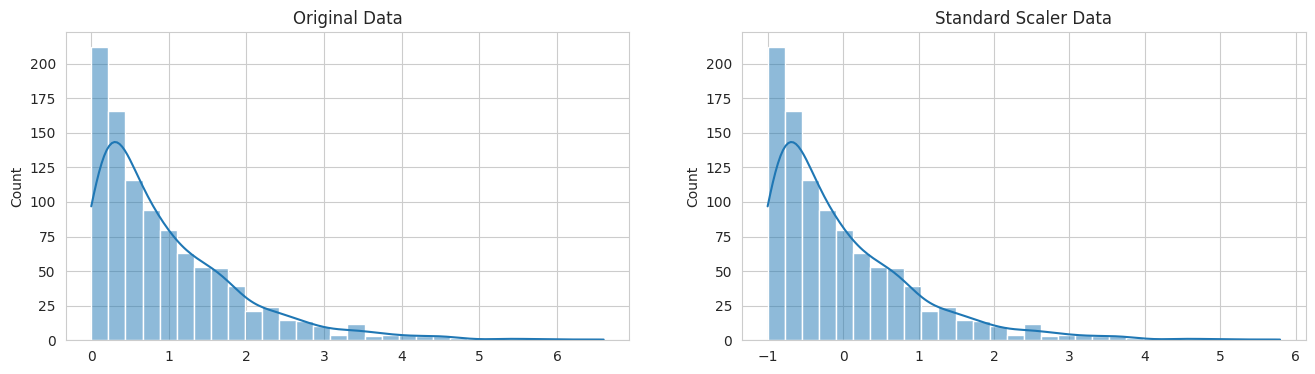

In [12]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

standard_scaler_data = standard_scaler.fit_transform(original_data.reshape(-1, 1))

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(standard_scaler_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title("Standard Scaler Data")
plt.show()

Standardization is quite different: first it subtracts the mean value (so standardized
values always have a zero mean), and then it divides by the standard deviation so that
the resulting distribution has unit variance. Unlike min-max scaling, standardization
does not bound values to a specific range, which may be a problem for some algo‐
rithms (e.g., neural networks often expect an input value ranging from 0 to 1). How‐
ever, standardization is much less affected by outliers.